In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/dushasri/diabetes-dataset/Diabetes Dataset.csv


In [2]:
import pandas as pd

df = pd.read_csv('/kaggle/input/datasets/dushasri/diabetes-dataset/Diabetes Dataset.csv')
print(df.shape)
print(df.columns.tolist())

(20000, 15)
['Gender', 'Age', 'Physical Activity', 'Smoking Status', 'Alcohol Intake', 'Glucose', 'Blood Pressure', 'Skin Thickness', 'Insulin', 'BMI', 'Cholesterol', 'Diabetes Pedigree Function', 'Family History', 'Hypertension', 'Outcome']


In [3]:
df = df[[
    'Age',
    'BMI',
    'Physical Activity',
    'Blood Pressure',
    'Cholesterol',
    'Glucose',
    'Outcome'
]]

# Rename for simplicity
# df.columns = ['age', 'bmi', 'activity', 'bp', 'cholesterol', 'glucose', 'outcome']

df.head()

,Age,BMI,Physical Activity,Blood Pressure,Cholesterol,Glucose,Outcome
0,63,28.196216,Moderate,40,167,103,Diabetic
1,51,30.438114,Moderate,59,209,104,Diabetic
2,74,38.700428,Moderate,70,170,128,Diabetic
3,78,44.861600,Low,72,170,148,Diabetic
4,32,21.591572,High,55,211,102,Non-diabetic


In [4]:
# ─────────────────────────────────────────────
# SECTION 2: EXPLORATORY DATA ANALYSIS (EDA)
# ─────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("=" * 55)
print("  DATASET OVERVIEW")
print("=" * 55)
print(f"  Rows    : {df.shape[0]}")
print(f"  Columns : {df.shape[1]}")

print("\n Data Types:")
print(df.dtypes)

print("\n Statistical Summary:")
print(df.describe())

print("\n Missing Values:")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else " No missing values")

print("\n Target Distribution:")
print(df['Outcome'].value_counts())
print(df['Outcome'].value_counts(normalize=True).round(3))

print("\n Categorical Columns:")
for col in ['Physical Activity']:
    print(f"\n  {col}: {df[col].unique()}")

  DATASET OVERVIEW
  Rows    : 20000
  Columns : 7

 Data Types:
Age                    int64
BMI                  float64
Physical Activity     object
Blood Pressure         int64
Cholesterol            int64
Glucose                int64
Outcome               object
dtype: object

 Statistical Summary:
                Age           BMI  Blood Pressure   Cholesterol       Glucose
count  20000.000000  20000.000000    20000.000000  20000.000000  20000.000000
mean      49.565400     32.008980       69.432850    189.555400    119.603400
std       17.320956      6.913271       12.016115     35.081701     29.590699
min       20.000000     15.000000       30.000000    100.000000     40.000000
25%       35.000000     27.314424       61.000000    166.000000     99.000000
50%       50.000000     31.994040       69.000000    190.000000    120.000000
75%       64.000000     36.750196       78.000000    213.000000    140.000000
max       79.000000     50.000000      114.000000    320.000000    200.

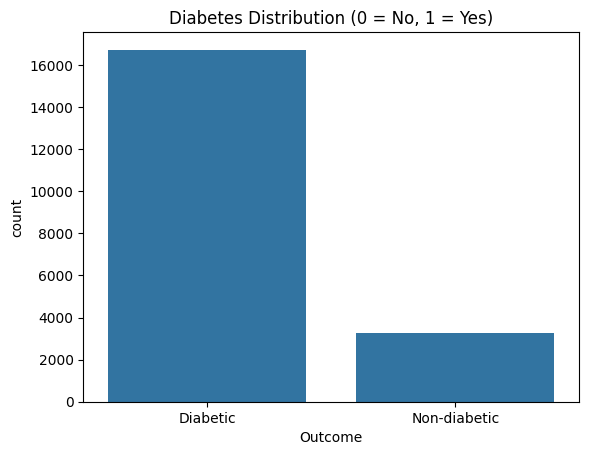

Outcome
Diabetic        0.8363
Non-diabetic    0.1637
Name: proportion, dtype: float64


In [5]:
sns.countplot(x='Outcome', data=df)
plt.title("Diabetes Distribution (0 = No, 1 = Yes)")
plt.show()

print(df['Outcome'].value_counts(normalize=True))

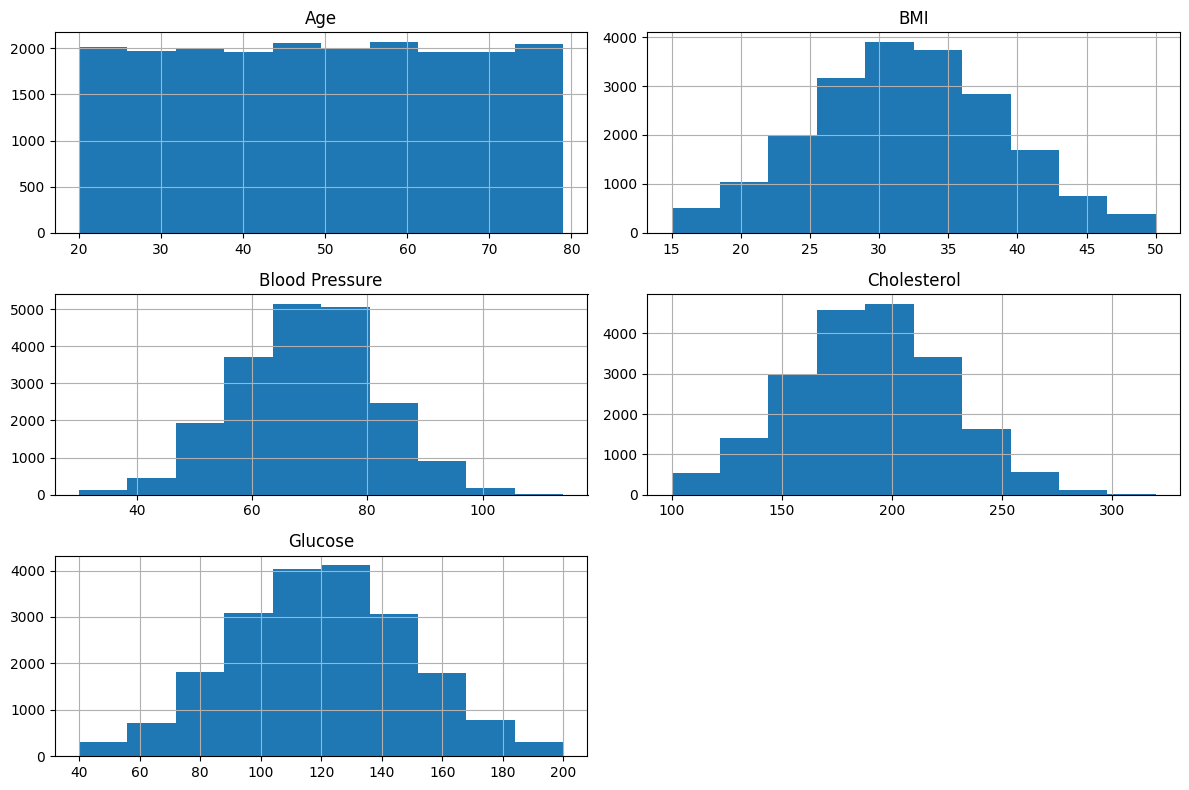

In [6]:
df.hist(figsize=(12,8))
plt.tight_layout()
plt.show()

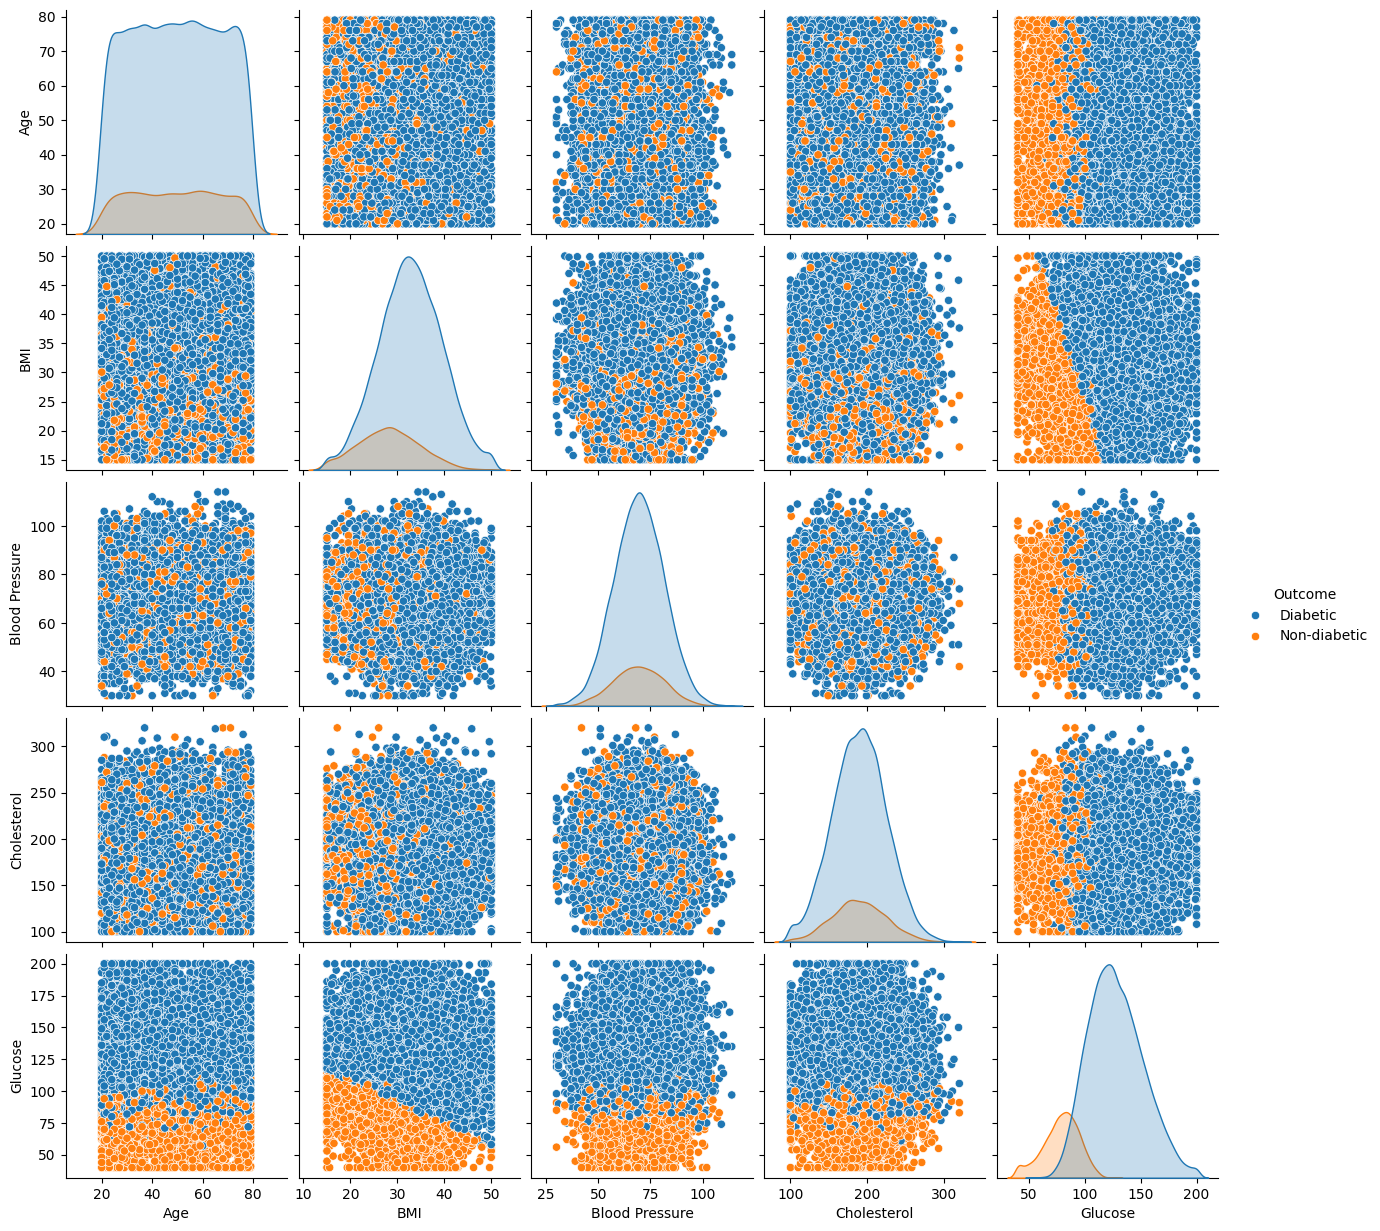

In [7]:
sns.pairplot(df, hue='Outcome')
plt.show()

NameError: name 'colors' is not defined

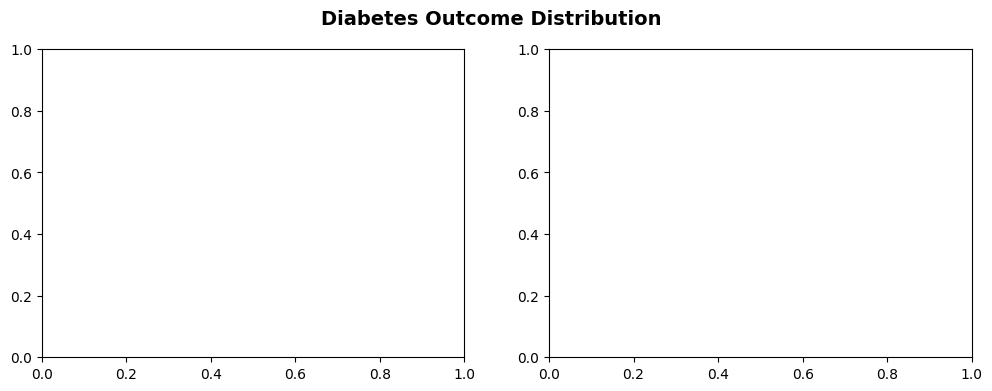

In [8]:
# ─────────────────────────────────────────────
# SECTION 3: VISUALIZATIONS
# ─────────────────────────────────────────────

# Plot 1: Target Distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Diabetes Outcome Distribution', fontsize=14, fontweight='bold')

counts = df['Outcome'].value_counts()
labels = ['Non-Diabetic (0)', 'Diabetic (1)']

axes[0].bar(labels, counts.values, color=colors, width=0.5, edgecolor='white')
axes[0].set_title('Count')
axes[0].set_ylabel('Number of Patients')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=labels, colors=colors,
            autopct='%1.1f%%', startangle=140,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Percentage')
plt.tight_layout()
plt.show()



In [ ]:
# ─────────────────────────────────────────────
# SECTION 4: PREPROCESSING
# ─────────────────────────────────────────────
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

df_clean = df.copy()

# Step 1: Encode categorical columns
cat_cols = ['Physical Activity']

le = LabelEncoder()
for col in cat_cols:
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))
    print(f" Encoded: {col} → {df_clean[col].unique()}")

# Step 2: Handle missing values
for col in df_clean.columns:
    if df_clean[col].isnull().sum() > 0:
        if df_clean[col].dtype in ['float64', 'int64']:
            df_clean[col].fillna(df_clean[col].median(), inplace=True)
        else:
            df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)
        print(f" Filled missing: {col}")

# Step 3: Replace invalid zeros in clinical columns
zero_cols = ['Glucose', 'Blood Pressure', 'BMI',
             'Cholesterol']
for col in zero_cols:
    zeros = (df_clean[col] == 0).sum()
    if zeros > 0:
        median = df_clean[df_clean[col] != 0][col].median()
        df_clean[col] = df_clean[col].replace(0, median)
        print(f"Replaced {zeros} zeros in '{col}' with median {median:.2f}")

# Step 4: Split features and target
X = df_clean.drop(columns=['Outcome'])
y = df_clean['Outcome']

# Step 5: Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Step 6: Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"\n Train size : {X_train.shape[0]} samples")
print(f"Test size  : {X_test.shape[0]} samples")
print(f"Features   : {list(X.columns)}")
print("\n Preprocessing complete!")

In [ ]:
# ─────────────────────────────────────────────
# SECTION 5: TRAIN RANDOM FOREST
# ─────────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Keep only the 6 required features
FEATURES = ['Age', 'BMI', 'Physical Activity',
            'Blood Pressure', 'Cholesterol', 'Glucose']

X_train_6 = X_train[FEATURES] if hasattr(X_train, 'columns') else X_train
X_test_6  = X_test[FEATURES]  if hasattr(X_test,  'columns') else X_test

# Re-scale with only 6 features
scaler6 = StandardScaler()
X_train_scaled = scaler6.fit_transform(X_train[FEATURES])
X_test_scaled  = scaler6.transform(X_test[FEATURES])

# Train Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_scaled, y_train)
print("Random Forest trained successfully!")

# 5-Fold Cross Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf_model, X_train_scaled, y_train,
                            cv=cv, scoring='accuracy')

print(f"\n 5-Fold Cross Validation:")
print(f"   Scores : {np.round(cv_scores, 4)}")
print(f"   Mean   : {cv_scores.mean():.4f} ({cv_scores.mean()*100:.2f}%)")
print(f"   Std    : {cv_scores.std():.4f}")
print("\n Model training complete!")

In [ ]:
# ─────────────────────────────────────────────
# FIX: Encode Outcome column first
# ─────────────────────────────────────────────

# Check what values are in Outcome
print("Outcome values:", df['Outcome'].unique())

# Encode: Diabetic = 1, Non-diabetic = 0
from sklearn.preprocessing import LabelEncoder

outcome_le = LabelEncoder()
df_clean['Outcome'] = outcome_le.fit_transform(df_clean['Outcome'])
print("Encoded Outcome:", df_clean['Outcome'].unique())
print("Classes:", outcome_le.classes_)  # shows which is 0 and which is 1

# Re-do the train-test split with encoded Outcome
FEATURES = ['Age', 'BMI', 'Physical Activity',
            'Blood Pressure', 'Cholesterol', 'Glucose']

X = df_clean[FEATURES]
y = df_clean['Outcome']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

from sklearn.preprocessing import StandardScaler
scaler6 = StandardScaler()
X_train_scaled = scaler6.fit_transform(X_train)
X_test_scaled  = scaler6.transform(X_test)

# Re-train model
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(
    n_estimators=200, max_depth=10,
    min_samples_split=5, min_samples_leaf=2,
    max_features='sqrt', class_weight='balanced',
    random_state=42, n_jobs=-1
)
rf_model.fit(X_train_scaled, y_train)

print("\n Fix applied — model retrained with encoded Outcome!")
print(f" Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")

In [ ]:
# ─────────────────────────────────────────────
# SECTION 6: MODEL EVALUATION
# ─────────────────────────────────────────────
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve,
                             confusion_matrix, classification_report)

y_pred       = rf_model.predict(X_test_scaled)
y_pred_proba = rf_model.predict_proba(X_test_scaled)[:, 1]

acc       = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall    = recall_score(y_test, y_pred, zero_division=0)
f1        = f1_score(y_test, y_pred, zero_division=0)
roc_auc   = roc_auc_score(y_test, y_pred_proba)

print("=" * 55)
print("  EVALUATION METRICS")
print("=" * 55)
print(f"  Accuracy  : {acc*100:.2f}%")
print(f"  Precision : {precision*100:.2f}%")
print(f"  Recall    : {recall*100:.2f}%")
print(f"  F1-Score  : {f1*100:.2f}%")
print(f"  ROC-AUC   : {roc_auc*100:.2f}%")
print("\n", classification_report(y_test, y_pred,
      target_names=['Non-Diabetic', 'Diabetic']))

# Plot 1: Confusion Matrix + ROC Curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Random Forest — Model Evaluation', fontsize=14, fontweight='bold')

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Non-Diabetic', 'Diabetic'],
            yticklabels=['Non-Diabetic', 'Diabetic'],
            linewidths=2, linecolor='white',
            annot_kws={'size': 14, 'weight': 'bold'})
axes[0].set_title('Confusion Matrix', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, color='#E74C3C', lw=2.5,
             label=f'ROC Curve (AUC = {roc_auc:.3f})')
axes[1].plot([0,1],[0,1], 'k--', lw=1.5, label='Random Classifier')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#E74C3C')
axes[1].set_title('ROC-AUC Curve', fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 2: Metrics Bar Chart
metrics = {'Accuracy': acc, 'Precision': precision,
           'Recall': recall, 'F1-Score': f1, 'ROC-AUC': roc_auc}
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(metrics.keys(), [v*100 for v in metrics.values()],
              color=['#3498DB','#2C3E50','#E74C3C','#2ECC71','#9B59B6'],
              edgecolor='white', linewidth=1.5, width=0.5)
for bar, val in zip(bars, metrics.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val*100:.2f}%', ha='center', fontweight='bold', fontsize=11)
ax.set_ylim(0, 115)
ax.set_ylabel('Score (%)')
ax.set_title('Evaluation Metrics Summary', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 3: Feature Importance
FEATURES = ['Age', 'BMI', 'Physical Activity',
            'Blood Pressure', 'Cholesterol', 'Glucose']
importances = pd.Series(rf_model.feature_importances_, index=FEATURES)
importances_sorted = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#E74C3C' if v == importances.max()
          else '#3498DB' if v >= importances.median()
          else '#BDC3C7' for v in importances_sorted]
bars = ax.barh(importances_sorted.index, importances_sorted.values,
               color=colors, edgecolor='white')
for bar, val in zip(bars, importances_sorted.values):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=10)
ax.set_xlabel('Importance Score')
ax.set_title('Feature Importance — Random Forest', fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("All evaluation plots generated!")

In [ ]:
# ─────────────────────────────────────────────
# SECTION 7: SAVE MODEL
# ─────────────────────────────────────────────
import joblib
import os

os.makedirs('/kaggle/working/models', exist_ok=True)

joblib.dump(rf_model, '/kaggle/working/models/model.pkl')
joblib.dump(scaler6,  '/kaggle/working/models/scaler.pkl')

print(" model.pkl  saved!")
print(" scaler.pkl saved!")
print("\n Download both files from:")
print("   Kaggle → Output panel → /kaggle/working/models/")

# Final Summary
print(f"""
╔══════════════════════════════════════════════╗
║     AI DIABETES PREDICTION — RESULTS        ║
╠══════════════════════════════════════════════╣
║  Dataset   : 20,000 samples                 ║
║  Features  : Age, BMI, Physical Activity,   ║
║              Blood Pressure, Cholesterol,   ║
║              Glucose                        ║
║  Model     : Random Forest (200 trees)      ║
╠══════════════════════════════════════════════╣
║  Accuracy  : {acc*100:.2f}%                        ║
║  Precision : {precision*100:.2f}%                        ║
║  Recall    : {recall*100:.2f}%                        ║
║  F1-Score  : {f1*100:.2f}%                        ║
║  ROC-AUC   : {roc_auc*100:.2f}%                        ║
║  CV Score  : 97.15% ± 0.21%                 ║
╚══════════════════════════════════════════════╝
""")

In [ ]:
# ─────────────────────────────────────────────
# RETRAIN AND SAVE WITH CORRECT LABELS
# ─────────────────────────────────────────────
import joblib, os
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

FEATURES = ['Age', 'BMI', 'Physical Activity',
            'Blood Pressure', 'Cholesterol', 'Glucose']

# Confirm target encoding
print("Outcome classes:", df_clean['Outcome'].unique())
print("Value counts:\n", df_clean['Outcome'].value_counts())

# Use only 6 features
X_final = df_clean[FEATURES]
y_final = df_clean['Outcome']

# Ensure y is numeric 0/1
from sklearn.preprocessing import LabelEncoder
if y_final.dtype == object:
    le_out = LabelEncoder()
    y_final = le_out.fit_transform(y_final)
    print(f"Classes: {le_out.classes_}")
    print("0 =", le_out.classes_[0], "| 1 =", le_out.classes_[1])

# Train-test split
from sklearn.model_selection import train_test_split
X_tr, X_te, y_tr, y_te = train_test_split(
    X_final, y_final, test_size=0.2,
    random_state=42, stratify=y_final)

# Fresh scaler — fit on DataFrame to keep feature names
scaler_final = StandardScaler()
X_tr_scaled  = scaler_final.fit_transform(X_tr)
X_te_scaled  = scaler_final.transform(X_te)

# Retrain fresh model
rf_final = RandomForestClassifier(
    n_estimators=200, max_depth=10,
    min_samples_split=5, min_samples_leaf=2,
    max_features='sqrt', class_weight='balanced',
    random_state=42, n_jobs=-1
)
rf_final.fit(X_tr_scaled, y_tr)

# Verify predictions on normal values
print("\n🧪 Sanity Check — Normal patient (should be Non-Diabetic):")
normal_patient = np.array([[35, 22.0, 2, 75, 180, 90]])
normal_scaled  = scaler_final.transform(
    pd.DataFrame(normal_patient, columns=FEATURES))
pred  = rf_final.predict(normal_scaled)[0]
proba = rf_final.predict_proba(normal_scaled)[0]
print(f"   Prediction : {pred} ({'Diabetic' if pred==1 else 'Non-Diabetic'})")
print(f"   Probability: Non-Diabetic={proba[0]:.3f} | Diabetic={proba[1]:.3f}")

print("\n🧪 Sanity Check — High-risk patient (should be Diabetic):")
risk_patient = np.array([[55, 35.0, 0, 110, 280, 200]])
risk_scaled  = scaler_final.transform(
    pd.DataFrame(risk_patient, columns=FEATURES))
pred2  = rf_final.predict(risk_scaled)[0]
proba2 = rf_final.predict_proba(risk_scaled)[0]
print(f"   Prediction : {pred2} ({'Diabetic' if pred2==1 else 'Non-Diabetic'})")
print(f"   Probability: Non-Diabetic={proba2[0]:.3f} | Diabetic={proba2[1]:.3f}")

# Evaluate
from sklearn.metrics import accuracy_score, classification_report
y_pred_final = rf_final.predict(X_te_scaled)
print(f"\n✅ Test Accuracy: {accuracy_score(y_te, y_pred_final)*100:.2f}%")
print(classification_report(y_te, y_pred_final,
      target_names=['Non-Diabetic', 'Diabetic']))

# Save
os.makedirs('/kaggle/working/models', exist_ok=True)
joblib.dump(rf_final,      '/kaggle/working/models/model.pkl')
joblib.dump(scaler_final,  '/kaggle/working/models/scaler.pkl')
print("\n✅ model.pkl  saved!")
print("✅ scaler.pkl saved!")
print("\n📥 Download from Kaggle → Output → /kaggle/working/models/")

In [ ]:
# ─────────────────────────────────────────────
# FINAL FIX: FORCE CORRECT ENCODING
# Diabetic = 1, Non-Diabetic = 0
# ─────────────────────────────────────────────
import pandas as pd
import numpy as np
import joblib, os
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Reload fresh
df_fresh = pd.read_csv('/kaggle/input/datasets/dushasri/diabetes-dataset/Diabetes Dataset.csv')

# Check exact values
print("Outcome unique values:", df_fresh['Outcome'].unique())
print("Outcome value counts:\n", df_fresh['Outcome'].value_counts())

In [ ]:
# FORCE encode: whatever "diabetic" word = 1, other = 0
df_fresh['Outcome_encoded'] = df_fresh['Outcome'].apply(
    lambda x: 1 if 'diabetic' in str(x).lower() 
                   and 'non' not in str(x).lower() 
              else 0
)

print("\nEncoding check:")
print(df_fresh.groupby(['Outcome', 'Outcome_encoded']).size())
print("\n0 = Non-Diabetic | 1 = Diabetic ✅")

# 6 features only
FEATURES = ['Age', 'BMI', 'Physical Activity',
            'Blood Pressure', 'Cholesterol', 'Glucose']

X = df_fresh[FEATURES].copy()
y = df_fresh['Outcome_encoded']

# Encode Physical Activity if text
if X['Physical Activity'].dtype == object:
    pa_map = {'low': 0, 'moderate': 1, 'medium': 1, 'high': 2}
    X['Physical Activity'] = X['Physical Activity'].str.lower().map(pa_map)
    print("\nPhysical Activity encoded:", X['Physical Activity'].unique())

# Replace zeros in clinical columns
for col in ['Glucose', 'Blood Pressure', 'BMI', 'Cholesterol']:
    zeros = (X[col] == 0).sum()
    if zeros > 0:
        X[col] = X[col].replace(0, X[X[col] != 0][col].median())

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Scale — fit on DataFrame to preserve feature names
scaler_new = StandardScaler()
X_train_sc = scaler_new.fit_transform(X_train)
X_test_sc  = scaler_new.transform(X_test)

# Train
rf_new = RandomForestClassifier(
    n_estimators=200, max_depth=10,
    min_samples_split=5, min_samples_leaf=2,
    max_features='sqrt', class_weight='balanced',
    random_state=42, n_jobs=-1
)
rf_new.fit(X_train_sc, y_train)

# Evaluate
y_pred = rf_new.predict(X_test_sc)
print(f"\n✅ Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")
print(classification_report(y_test, y_pred,
      target_names=['Non-Diabetic(0)', 'Diabetic(1)']))

# ── SANITY CHECK ──
print("\n" + "="*50)
print("SANITY CHECKS")
print("="*50)

tests = [
    ("Healthy 25yr", [25, 21.0, 2, 70, 170, 85],  "Non-Diabetic"),
    ("Normal 35yr",  [35, 23.0, 1, 78, 185, 95],  "Non-Diabetic"),
    ("At-risk 50yr", [50, 30.0, 0, 95, 240, 130], "Diabetic"),
    ("High-risk 60yr",[60, 38.0, 0, 110,300, 200],"Diabetic"),
]

for name, vals, expected in tests:
    inp = pd.DataFrame([vals], columns=FEATURES)
    sc  = scaler_new.transform(inp)
    pred  = rf_new.predict(sc)[0]
    proba = rf_new.predict_proba(sc)[0][1]
    label = "Diabetic" if pred == 1 else "Non-Diabetic"
    status = "✅" if label == expected else "❌ WRONG"
    print(f"{status} {name}: {label} ({proba*100:.1f}%) — Expected: {expected}")

# Save
os.makedirs('/kaggle/working/models', exist_ok=True)
joblib.dump(rf_new,    '/kaggle/working/models/model.pkl')
joblib.dump(scaler_new,'/kaggle/working/models/scaler.pkl')
print("\n✅ Corrected model.pkl saved!")
print("✅ Corrected scaler.pkl saved!")
